# Rail Corrugation
## Axle Spatial Analysis

This notebook investigates whether corrugation produces spatially different responses across the 64 axle-box sensors.

Objectives:
- Calculate vibration RMS for each axle-box
- Map sensors to car and axle position
- Compare spatial vibration patterns across classes
- Identify positions or cars that may contain useful information

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
DATA_DIR = Path("..")
TRAIN_PATH = DATA_DIR / "Train"

labels = pd.read_csv(DATA_DIR / "Train_Labels.csv")

In [3]:
sample = pd.read_csv(TRAIN_PATH / "Train1.csv")

vib_cols = [c for c in sample.columns if "vibration" in c.lower()]

print("Vibration channels:", len(vib_cols))

Vibration channels: 64


## Sensor Layout

The train contains:

- 8 cars
- 8 axle-box positions per car
- 64 vibration sensors in total

For each car:

- Positions 1, 3, 5, 7 → Side I
- Positions 2, 4, 6, 8 → Side II

In [5]:
display(vib_cols)

['Vibration of bearing in position 1 of car 1',
 'Vibration of bearing in position 2 of car 1',
 'Vibration of bearing in position 3 of car 1',
 'Vibration of bearing in position 4 of car 1',
 'Vibration of bearing in position 5 of car 1',
 'Vibration of bearing in position 6 of car 1',
 'Vibration of bearing in position 7 of car 1',
 'Vibration of bearing in position 8 of car 1',
 'Vibration of bearing in position 1 of car 2',
 'Vibration of bearing in position 2 of car 2',
 'Vibration of bearing in position 3 of car 2',
 'Vibration of bearing in position 4 of car 2',
 'Vibration of bearing in position 5 of car 2',
 'Vibration of bearing in position 6 of car 2',
 'Vibration of bearing in position 7 of car 2',
 'Vibration of bearing in position 8 of car 2',
 'Vibration of bearing in position 1 of car 3',
 'Vibration of bearing in position 2 of car 3',
 'Vibration of bearing in position 3 of car 3',
 'Vibration of bearing in position 4 of car 3',
 'Vibration of bearing in position 5 of 

## Axle-Box RMS

Instead of combining all sensors on one side, we calculate vibration RMS independently for each axle box.

This preserves the spatial information that was removed in the previous feature engineering approach.

In [6]:
def axle_rms(data):
    return {
        col: np.sqrt(np.mean(data[col].to_numpy() ** 2))
        for col in vib_cols
    }

In [7]:
rms_test = axle_rms(sample)

display(pd.Series(rms_test).head(10))

Vibration of bearing in position 1 of car 1    0.289549
Vibration of bearing in position 2 of car 1    0.100103
Vibration of bearing in position 3 of car 1    0.115299
Vibration of bearing in position 4 of car 1    0.092211
Vibration of bearing in position 5 of car 1    0.152307
Vibration of bearing in position 6 of car 1    0.121617
Vibration of bearing in position 7 of car 1    0.141645
Vibration of bearing in position 8 of car 1    0.115948
Vibration of bearing in position 1 of car 2    0.329671
Vibration of bearing in position 2 of car 2    0.263028
dtype: float64

In [8]:
rows = []

for _, row in labels.iterrows():
    data = pd.read_csv(TRAIN_PATH / row["filename"])

    values = axle_rms(data)
    values["filename"] = row["filename"]
    values["label"] = row["label"]

    rows.append(values)

axle_df = pd.DataFrame(rows)

In [9]:
print(axle_df.shape)
display(axle_df.head())

(272, 66)


,Vibration of bearing in position 1 of car 1,Vibration of bearing in position 2 of car 1,Vibration of bearing in position 3 of car 1,Vibration of bearing in position 4 of car 1,Vibration of bearing in position 5 of car 1,Vibration of bearing in position 6 of car 1,Vibration of bearing in position 7 of car 1,Vibration of bearing in position 8 of car 1,Vibration of bearing in position 1 of car 2,Vibration of bearing in position 2 of car 2,...,Vibration of bearing in position 1 of car 8,Vibration of bearing in position 2 of car 8,Vibration of bearing in position 3 of car 8,Vibration of bearing in position 4 of car 8,Vibration of bearing in position 5 of car 8,Vibration of bearing in position 6 of car 8,Vibration of bearing in position 7 of car 8,Vibration of bearing in position 8 of car 8,filename,label
0,0.289549,0.100103,0.115299,0.092211,0.152307,0.121617,0.141645,0.115948,0.329671,0.263028,...,0.172309,0.048421,0.071402,0.069795,0.163936,0.158953,0.155132,0.222388,Train1.csv,Normal
1,0.400369,0.280458,0.637965,0.378077,0.368920,0.229614,0.519019,0.348228,0.745736,0.455185,...,0.253132,0.231356,0.071966,0.229245,0.330421,0.473896,0.279762,0.390921,Train2.csv,Side II
2,0.309034,0.391535,0.302463,0.315671,0.333674,0.433499,0.384450,0.360140,0.362717,0.470020,...,0.284540,0.207831,0.078159,0.257784,0.771320,0.764131,0.880707,0.941192,Train3.csv,Normal
3,0.206462,0.282924,0.209335,0.174002,0.121548,0.123571,0.159451,0.159921,0.330917,0.385182,...,0.326265,0.566935,0.078156,0.874225,0.446876,0.962261,0.599073,1.191042,Train4.csv,Normal
4,0.097121,0.055607,0.043558,0.061748,0.043911,0.059990,0.107648,0.095926,0.060210,0.032620,...,0.071061,0.034878,0.073410,0.050157,0.126152,0.069590,0.037735,0.061051,Train5.csv,Normal


## Class-Level Spatial Pattern

We calculate the mean RMS at each axle-box location for each class.

This allows us to see whether particular cars or axle positions respond differently to corrugation.

In [11]:
sensor_means = axle_df.groupby("label")[vib_cols].mean()

display(sensor_means)

,Vibration of bearing in position 1 of car 1,Vibration of bearing in position 2 of car 1,Vibration of bearing in position 3 of car 1,Vibration of bearing in position 4 of car 1,Vibration of bearing in position 5 of car 1,Vibration of bearing in position 6 of car 1,Vibration of bearing in position 7 of car 1,Vibration of bearing in position 8 of car 1,Vibration of bearing in position 1 of car 2,Vibration of bearing in position 2 of car 2,...,Vibration of bearing in position 7 of car 7,Vibration of bearing in position 8 of car 7,Vibration of bearing in position 1 of car 8,Vibration of bearing in position 2 of car 8,Vibration of bearing in position 3 of car 8,Vibration of bearing in position 4 of car 8,Vibration of bearing in position 5 of car 8,Vibration of bearing in position 6 of car 8,Vibration of bearing in position 7 of car 8,Vibration of bearing in position 8 of car 8
label,,,,,,,,,,,,,,,,,,,,,
Normal,0.251110,0.245652,0.227293,0.247166,0.223861,0.265619,0.251943,0.284479,0.248209,0.250766,...,0.304356,0.256895,0.263878,0.235923,0.075027,0.255125,0.280008,0.231091,0.256863,0.264549
Side I,0.230093,0.236921,0.227803,0.265218,0.252302,0.223192,0.301809,0.287754,0.358630,0.396002,...,0.557311,0.254182,0.714577,0.475231,0.075623,0.445924,0.721780,0.508338,0.664120,0.579489
Side II,0.491046,0.922808,0.472358,0.932018,0.445032,0.797978,0.469868,0.781018,0.463234,0.604254,...,0.571546,0.416568,0.611463,0.874352,0.074901,0.773637,0.575122,0.822942,0.589259,0.771923


## Spatial RMS Maps

Each recording is represented as an 8 × 8 matrix:

Rows → Car 1 to Car 8  
Columns → Axle positions 1 to 8

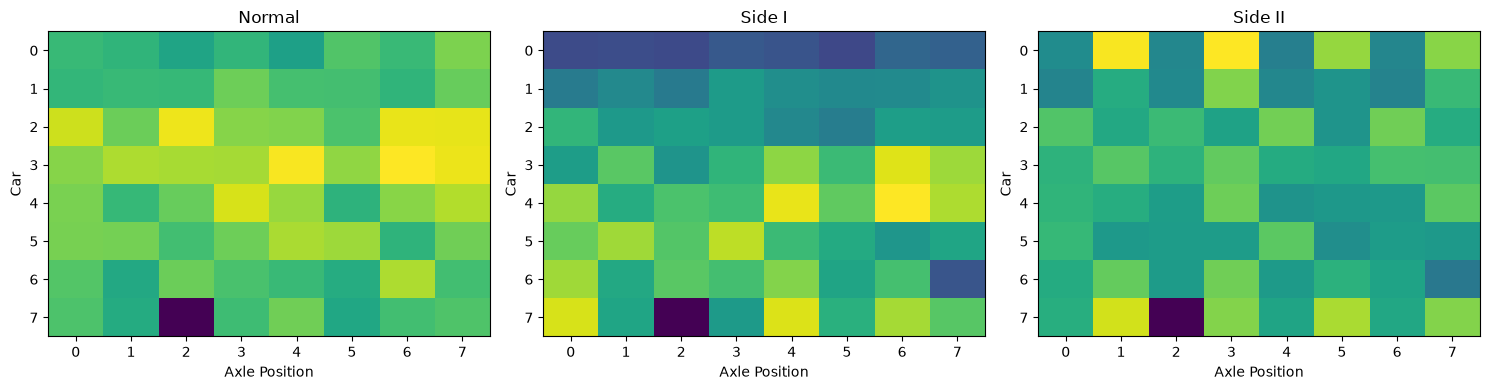

In [13]:
def spatial_matrix(values):
    return np.array(values).reshape(8, 8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, label in zip(axes, ["Normal", "Side I", "Side II"]):
    matrix = spatial_matrix(sensor_means.loc[label])

    im = ax.imshow(matrix, aspect="auto")
    ax.set_title(label)
    ax.set_xlabel("Axle Position")
    ax.set_ylabel("Car")

plt.tight_layout()
plt.show()

## Side-Specific Spatial Response

We compare the average RMS of the four positions belonging to each rail side for every car.

In [14]:
side1_cols = [c for c in vib_cols if any(f"position {p}" in c.lower() for p in [1, 3, 5, 7])]
side2_cols = [c for c in vib_cols if any(f"position {p}" in c.lower() for p in [2, 4, 6, 8])]

In [20]:
car_side_results = []

for label in ["Normal", "Side I", "Side II"]:
    subset = axle_df[axle_df["label"] == label]

    for car in range(1, 9):
        car1 = [c for c in side1_cols if c.lower().endswith(f"car {car}")]
        car2 = [c for c in side2_cols if c.lower().endswith(f"car {car}")]

        car_side_results.append({
            "label": label,
            "car": car,
            "side1_rms": subset[car1].mean().mean(),
            "side2_rms": subset[car2].mean().mean()
        })

car_df = pd.DataFrame(car_side_results)

display(car_df)

,label,car,side1_rms,side2_rms
0,Normal,1,0.238552,0.260729
1,Normal,2,0.250803,0.265798
2,Normal,3,0.315250,0.289154
3,Normal,4,0.315138,0.306769
4,Normal,5,0.286463,0.280289
5,Normal,6,0.271951,0.284658
6,Normal,7,0.275331,0.246917
7,Normal,8,0.218944,0.246672
8,Side I,1,0.253002,0.253271
9,Side I,2,0.382271,0.417180


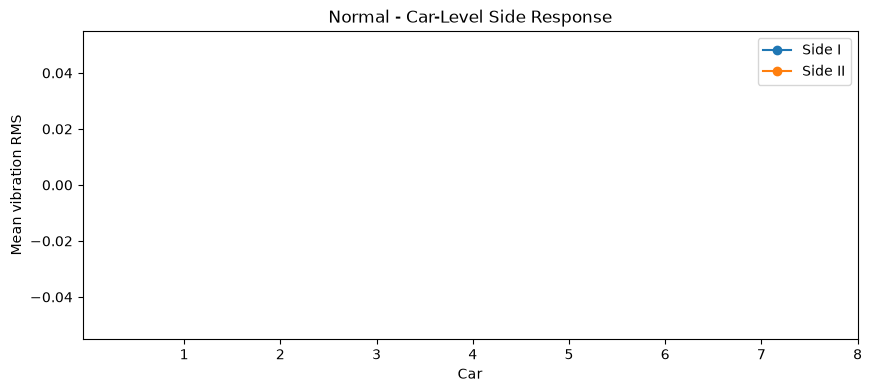

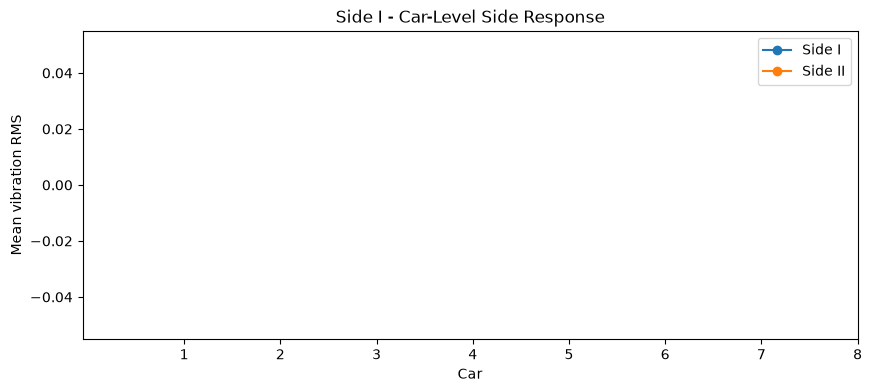

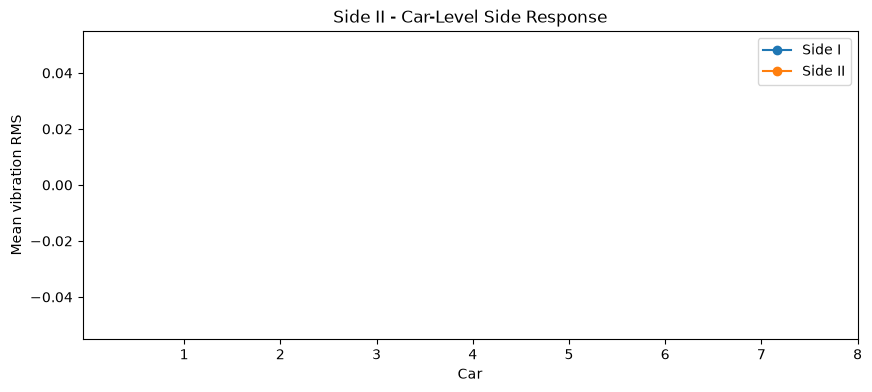

In [16]:
for label in ["Normal", "Side I", "Side II"]:
    subset = car_df[car_df["label"] == label]

    plt.figure(figsize=(10, 4))
    plt.plot(subset["car"], subset["side1_rms"], marker="o", label="Side I")
    plt.plot(subset["car"], subset["side2_rms"], marker="o", label="Side II")

    plt.xlabel("Car")
    plt.ylabel("Mean vibration RMS")
    plt.title(f"{label} - Car-Level Side Response")
    plt.xticks(range(1, 9))
    plt.legend()
    plt.show()

## Axle Position Response

We now ignore the car number and examine whether particular axle positions systematically behave differently.

This helps determine whether the position itself or the rail side is the stronger spatial factor.

In [18]:
position_results = []

for label in ["Normal", "Side I", "Side II"]:
    subset = axle_df[axle_df["label"] == label]

    for position in range(1, 9):
        cols = [
            c for c in vib_cols
            if f"position {position}" in c.lower()
        ]

        position_results.append({
            "label": label,
            "position": position,
            "rms": subset[cols].mean().mean()
        })

position_df = pd.DataFrame(position_results)

display(position_df)

,label,position,rms
0,Normal,1,0.275083
1,Normal,2,0.259916
2,Normal,3,0.249475
3,Normal,4,0.278895
4,Normal,5,0.279430
5,Normal,6,0.261187
6,Normal,7,0.282228
7,Normal,8,0.290494
8,Side I,1,0.524158
9,Side I,2,0.472058


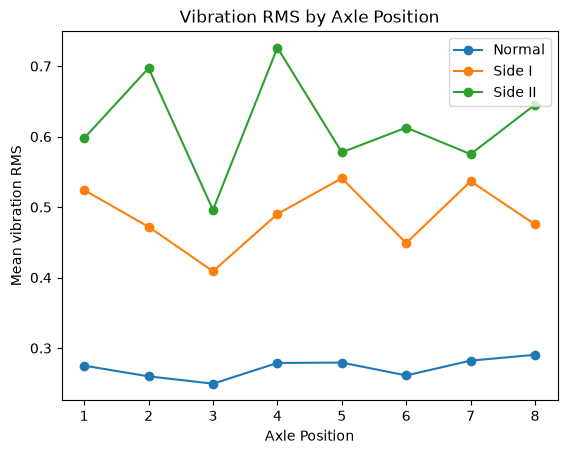

In [19]:
for label in ["Normal", "Side I", "Side II"]:
    subset = position_df[position_df["label"] == label]

    plt.plot(
        subset["position"],
        subset["rms"],
        marker="o",
        label=label
    )

plt.xlabel("Axle Position")
plt.ylabel("Mean vibration RMS")
plt.title("Vibration RMS by Axle Position")
plt.xticks(range(1, 9))
plt.legend()
plt.show()

## Paired Position Asymmetry

Each Side I axle position has a corresponding Side II position:

- Position 1 vs 2
- Position 3 vs 4
- Position 5 vs 6
- Position 7 vs 8

We compare these pairs to determine whether local side asymmetry contains more information than a single train-wide Side I vs Side II difference.

In [21]:
pair_results = []

for label in ["Normal", "Side I", "Side II"]:
    subset = axle_df[axle_df["label"] == label]

    for p1, p2 in [(1, 2), (3, 4), (5, 6), (7, 8)]:
        cols1 = [c for c in vib_cols if f"position {p1} " in c.lower()]
        cols2 = [c for c in vib_cols if f"position {p2} " in c.lower()]

        diff = subset[cols1].mean(axis=1) - subset[cols2].mean(axis=1)

        pair_results.append({
            "label": label,
            "pair": f"{p1}-{p2}",
            "mean_diff": diff.mean(),
            "std_diff": diff.std()
        })

pair_df = pd.DataFrame(pair_results)

display(pair_df)

,label,pair,mean_diff,std_diff
0,Normal,1-2,0.015167,0.043689
1,Normal,3-4,-0.029420,0.056008
2,Normal,5-6,0.018243,0.043325
3,Normal,7-8,-0.008266,0.049170
4,Side I,1-2,0.052100,0.103390
5,Side I,3-4,-0.081194,0.101962
6,Side I,5-6,0.091925,0.082585
7,Side I,7-8,0.061212,0.086178
8,Side II,1-2,-0.099524,0.090354
9,Side II,3-4,-0.230081,0.114935


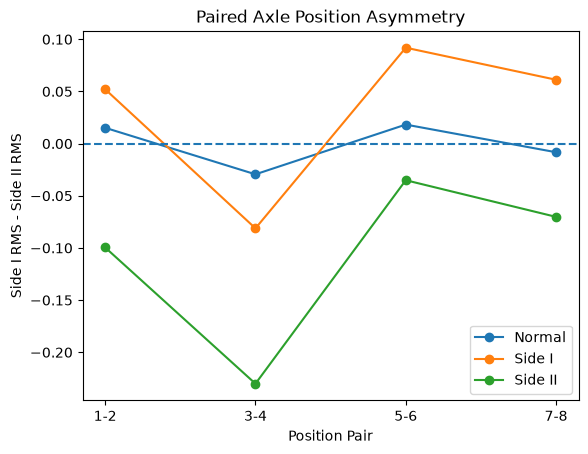

In [22]:
for label in ["Normal", "Side I", "Side II"]:
    subset = pair_df[pair_df["label"] == label]

    plt.plot(
        subset["pair"],
        subset["mean_diff"],
        marker="o",
        label=label
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Position Pair")
plt.ylabel("Side I RMS - Side II RMS")
plt.title("Paired Axle Position Asymmetry")
plt.legend()
plt.show()

In [23]:
pair_features = pd.DataFrame({
    "1-2": axle_df[[c for c in vib_cols if "position 1 " in c.lower()]].mean(axis=1)
         - axle_df[[c for c in vib_cols if "position 2 " in c.lower()]].mean(axis=1),

    "3-4": axle_df[[c for c in vib_cols if "position 3 " in c.lower()]].mean(axis=1)
         - axle_df[[c for c in vib_cols if "position 4 " in c.lower()]].mean(axis=1),

    "5-6": axle_df[[c for c in vib_cols if "position 5 " in c.lower()]].mean(axis=1)
         - axle_df[[c for c in vib_cols if "position 6 " in c.lower()]].mean(axis=1),

    "7-8": axle_df[[c for c in vib_cols if "position 7 " in c.lower()]].mean(axis=1)
         - axle_df[[c for c in vib_cols if "position 8 " in c.lower()]].mean(axis=1),

    "label": axle_df["label"]
})

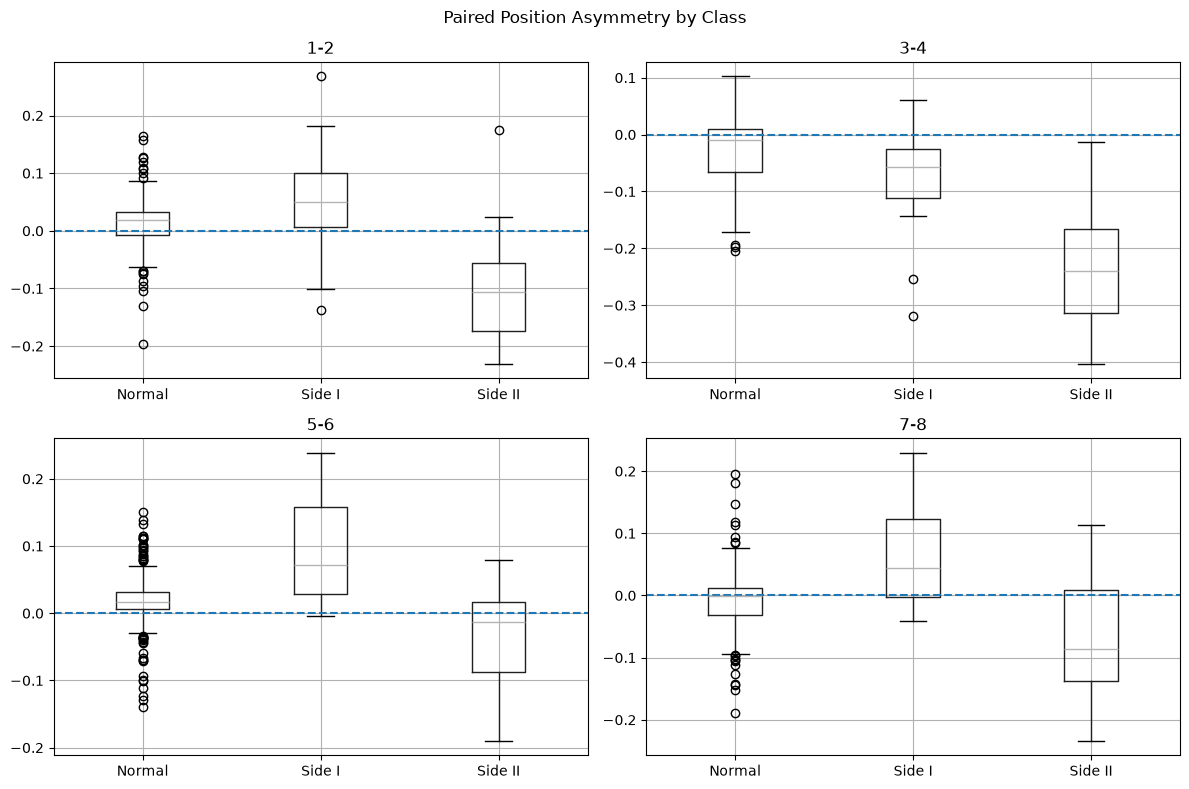

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, pair in zip(axes.ravel(), ["1-2", "3-4", "5-6", "7-8"]):
    pair_features.boxplot(column=pair, by="label", ax=ax)
    ax.axhline(0, linestyle="--")
    ax.set_title(pair)
    ax.set_xlabel("")

plt.suptitle("Paired Position Asymmetry by Class")
plt.tight_layout()
plt.show()